## 環境設置

In [1]:
try:
    import openseespy.opensees as ops  # noqa: F401
except ImportError:
    import sys
    !{sys.executable} -m pip install -q openseespy
    import openseespy.opensees as ops  # noqa: F401

try:
    import numpy as np  # noqa: F401
except ImportError:
    import sys
    !{sys.executable} -m pip install -q numpy

# Case-03.6:快速強度檢核

依 [ROADMAP.md](../ROADMAP.md) 規劃,這一步補上 Case-03.5 完全沒做的
事——**Case-03.5 只檢核了層間位移角,完全沒檢核柱子扛不扛得住力**。
這裡引入軸力、彎矩、剪力三項強度檢核,依據《結構混凝土設計規範》
第 21 章(強度折減因數)與第 22 章(斷面強度)的規定公式。

**彎矩強度用應變相容法計算**(規範 P-M 交互作用圖背後的正規算法)
——這裡明確記一筆:這個檔案原本用的是簡化的單筋梁公式
(`Mn=As*fy*(d-a/2)`,把全部縱向鋼筋當拉力鋼筋),誤用在柱斷面上
高估了抗彎強度(對稱配筋的柱子,只有部分鋼筋真正在受拉面出力)。
完整發現過程見 `ROADMAP.md` 的 VL-04、VL-05。修正後直接更新本檔案,
不另開副本——理由跟過程寫在 ROADMAP,程式碼本身保持最新、正確的
版本。

**定位**:這仍然是 **Design(設計檢核)**,產出的還是分析模型用的
初始斷面,不是最終施工圖配筋。

## 第 1 課:需求力——延續 Case-03.5

沿用 Case-03.5 已經算出的單榀構架分擔力(F1_frame、F2_frame),重新
跑一次 Case-03(剪力構架)的分析拿到 1F 柱端內力(Mu、Vu)。

**關鍵觀察**:因為這個構架左右兩柱斷面永遠相同(對稱),柱端彎矩
M=V×h/2 只跟「總力」與「高度」有關,**跟柱斷面大小本身無關**。

In [2]:
E = 2.463e7
h1 = h2 = 3.5
L = 6.0
F1_frame, F2_frame = 9.938, 15.900   # 沿用Case-03.5

def analyze_frame(h_col):
    """沿用Case-03驗證過的剪力構架建模方法, 回傳(drift1, drift2, Mu, Vu)"""
    Ic = h_col**4/12
    ops.wipe()
    ops.model('basic', '-ndm', 2, '-ndf', 3)
    ops.node(1, 0.0, 0.0);   ops.node(2, L, 0.0)
    ops.node(3, 0.0, h1);    ops.node(4, L, h1)
    ops.node(5, 0.0, h1+h2); ops.node(6, L, h1+h2)
    ops.fix(1,1,1,1); ops.fix(2,1,1,1)
    for n in [3,4,5,6]:
        ops.fix(n, 0,1,1)
    ops.equalDOF(3,4,1); ops.equalDOF(5,6,1)
    A_big = 1.0e6
    ops.geomTransf('Linear', 1)
    ops.element('elasticBeamColumn',1,1,3,A_big,E,Ic,1)
    ops.element('elasticBeamColumn',2,2,4,A_big,E,Ic,1)
    ops.element('elasticBeamColumn',3,3,5,A_big,E,Ic,1)
    ops.element('elasticBeamColumn',4,4,6,A_big,E,Ic,1)
    ops.timeSeries('Linear',1); ops.pattern('Plain',1,1)
    ops.load(3, F1_frame, 0.0, 0.0)
    ops.load(5, F2_frame, 0.0, 0.0)
    ops.system('BandGeneral'); ops.numberer('RCM'); ops.constraints('Transformation')
    ops.test('NormDispIncr',1e-10,20); ops.algorithm('Newton')
    ops.integrator('LoadControl',1.0); ops.analysis('Static'); ops.analyze(1)
    u1 = ops.nodeDisp(3,1); u2 = ops.nodeDisp(5,1)
    f1 = ops.eleForce(1)
    return u1/h1, (u2-u1)/h2, abs(f1[2]), abs(f1[1])

drift1_40, drift2_40, Mu, Vu = analyze_frame(0.40)
print(f"1F柱端彎矩需求 Mu = {Mu:.3f} kN-m")
print(f"1F柱剪力需求   Vu = {Vu:.3f} kN")
print(f"(這兩個數字不會隨斷面大小改變, 下面掃描不同尺寸時直接沿用)")

1F柱端彎矩需求 Mu = 22.608 kN-m
1F柱剪力需求   Vu = 0.000 kN
(這兩個數字不會隨斷面大小改變, 下面掃描不同尺寸時直接沿用)


## 第 2 課:重力軸力概估(需求端最後一項)

到目前為止的分析都只有側向地震力,完全沒有算重力載重——軸力檢核需要
重力軸力。這裡用概略從屬面積估算(邊柱、半跨×半跨),**不是完整的
荷重歸集**,只求數量級合理,足夠支撐「快速檢核」的用途。

In [3]:
D_floor, L_floor = 5.0, 2.5   # kN/m^2, 呼應桃園案例假設值
D_roof,  L_roof  = 4.0, 1.0
trib_area = 3.0*3.0   # m^2, 概估邊柱從屬面積(半跨x半跨)

Pu = 1.2*(D_floor+D_roof)*trib_area + 1.6*(L_floor+L_roof)*trib_area
print(f"Pu(1F柱軸力需求, 概估從屬面積{trib_area}m^2) = {Pu:.2f} kN")
print(f"載重組合: 1.2D+1.6L(強度設計法典型組合)")

Pu(1F柱軸力需求, 概估從屬面積9.0m^2) = 147.60 kN
載重組合: 1.2D+1.6L(強度設計法典型組合)


## 第 3 課:規範強度公式(《結構混凝土設計規範》)

**強度折減因數**(表 21.2.2,彎矩/軸力/合併作用):

| 淨拉應變分類 | φ(箍筋柱,非螺箍) |
|---|---|
| 壓力控制(εt ≤ εty) | 0.65 |
| 拉力控制(εt ≥ εty+0.003) | 0.90 |
| 過渡區 | 線性內插 |

這裡**保守取 φ=0.65**(壓力控制,箍筋柱最低值),不做完整過渡區判定
——這個簡化本身沒有問題,是刻意偏安全的選擇。

**彎矩強度用應變相容法**(平面保持平面+力平衡,規範 P-M 交互作用圖
的正規算法)——不是套用單筋梁公式。8 根鋼筋依實際位置分層(受壓側3根
+中央2根+受拉側3根),逐層算應變、應力,積分得到真正的 Mn。

**軸力上限**(式 22.4.2.2、表 22.4.2.1a,這個公式本身沒有問題,
軸力是全部鋼筋同時受壓,跟彎矩的受拉/受壓分區問題不同):

$$P_o = 0.85f_c'(A_g-A_{st}) + f_yA_{st}, \qquad P_{n,max}=0.80P_o$$

**混凝土剪力強度**(這個公式對梁柱通用,沒有梁柱誤用的問題):

$$V_c = 0.53\sqrt{f_c'}\,b_wd$$

> **單位提醒**:這幾條公式用規範原文的傳統單位制(kgf/cm²、cm),
> 不是 SI,計算時要注意跟前面 Case 用的 kN/m 制正確換算。

In [4]:
fc = 280.0    # kgf/cm^2
fy = 4200.0   # kgf/cm^2 (SD420鋼筋)
Es = 2.0e6    # kgf/cm^2 (鋼筋標準彈性模數)
beta1 = 0.85
eps_cu = 0.003
rho_assume = 0.02   # 假設縱向鋼筋比(quick check用, 非實際配筋設計)

phi_axial = phi_moment = 0.65   # 表21.2.2, 保守取壓力控制
phi_shear = 0.75                # 表21.2.1(b)


def Mn_strain_compat(h_col_m, Pu_kN):
    """應變相容法算標稱彎矩強度(取代單筋梁公式)
    h_col_m=柱邊長(m), Pu_kN=軸力(kN, 壓力正值)"""
    h = h_col_m*100
    cover = 4.0
    half = h/2 - cover
    if half <= 0:
        return 0.0

    As_bar = (rho_assume*h*h)/8
    bar_layers = {half: 3, 0.0: 2, -half: 3}   # 8根鋼筋: 壓力側3+中央2+拉力側3

    Pu_kgf = Pu_kN*1000/9.80665
    eps_y = fy/Es

    def section_force(c):
        a = min(beta1*c, h)
        Cc = 0.85*fc*h*a
        y_Cc = half - a/2
        N, M = Cc, Cc*y_Cc
        for y, n_bars in bar_layers.items():
            As = n_bars*As_bar
            dist = half - y
            eps_s = eps_cu*(c-dist)/c if c > 0 else 0.0
            eps_s = max(min(eps_s, eps_y), -eps_y)
            fs = Es*eps_s
            fs_net = fs - 0.85*fc if dist <= a else fs
            Fs = As*fs_net
            N += Fs; M += Fs*y
        return N, M

    c_lo, c_hi = 0.1, h*3
    for _ in range(100):
        c_mid = (c_lo+c_hi)/2
        N, _ = section_force(c_mid)
        if N > Pu_kgf:
            c_hi = c_mid
        else:
            c_lo = c_mid
    _, M_final = section_force((c_lo+c_hi)/2)
    return M_final*9.80665e-5   # kgf-cm -> kN-m


def strength_capacity(h_col_m):
    """給定方形柱邊長(m), 回傳(phiPn_kN, phiMn_kNm, phiVc_kN)"""
    b = d = h_col_m*100
    Ag = b*d
    Ast = rho_assume*Ag

    Po = 0.85*fc*(Ag-Ast) + fy*Ast
    Pn_max = 0.80*Po
    phiPn_kN = phi_axial*Pn_max*9.80665e-3

    Mn_kNm = Mn_strain_compat(h_col_m, Pu)
    phiMn_kNm = phi_moment*Mn_kNm

    Vc = 0.53*(fc**0.5)*b*d
    phiVc_kN = phi_shear*Vc*9.80665e-3

    return phiPn_kN, phiMn_kNm, phiVc_kN


# 驗證: 40cm柱應與Case-06纖維斷面/應變相容法結果吻合
_, phiMn_40, _ = strength_capacity(0.40)
Mn_40_check = phiMn_40/phi_moment
assert abs(Mn_40_check - 220.83) < 0.5, "跟Case-06驗證過的應變相容法結果對不起來!"
print(f"[PASS] 40cm柱 Mn = {Mn_40_check:.2f} kN-m, 與Case-06纖維斷面驗證結果一致")

[PASS] 40cm柱 Mn = 220.83 kN-m, 與Case-06纖維斷面驗證結果一致


## 第 4 課:候選斷面掃描——位移角與強度雙重檢核

In [5]:
DRIFT_LIMIT = 0.005
candidate_sizes_cm = [15, 18, 20, 25, 30, 35, 40]

results = []
for s in candidate_sizes_cm:
    h_col = s/100
    d1, d2, Mu_i, Vu_i = analyze_frame(h_col)
    phiPn, phiMn, phiVc = strength_capacity(h_col)

    drift_ok = d1 < DRIFT_LIMIT and d2 < DRIFT_LIMIT
    m_util = Mu_i/phiMn
    v_util = Vu_i/phiVc if phiVc > 0 else 0.0
    p_util = Pu/phiPn
    strength_ok = m_util < 1.0 and v_util < 1.0 and p_util < 1.0
    overall_ok = drift_ok and strength_ok

    results.append(dict(size=s, drift1=d1, drift_ok=drift_ok,
                         m_util=m_util, v_util=v_util, p_util=p_util,
                         strength_ok=strength_ok, overall_ok=overall_ok))

print(f"{'尺寸':<8}{'drift1':<12}{'位移角':<8}{'M利用率':<10}{'強度':<8}{'總結':<8}")
for r in results:
    print(f"{r['size']}cm    {r['drift1']:<12.6f}"
          f"{'PASS' if r['drift_ok'] else 'FAIL':<8}"
          f"{r['m_util']:<10.1%}"
          f"{'PASS' if r['strength_ok'] else 'FAIL':<8}"
          f"{'PASS' if r['overall_ok'] else 'FAIL':<8}")

尺寸      drift1      位移角     M利用率      強度      總結      
15cm    0.012692    FAIL    534.9%    FAIL    FAIL    
18cm    0.006121    FAIL    236.5%    FAIL    FAIL    
20cm    0.004016    PASS    159.0%    FAIL    FAIL    
25cm    0.001645    PASS    71.8%     PASS    PASS    
30cm    0.000793    PASS    39.0%     PASS    PASS    
35cm    0.000428    PASS    23.9%     PASS    PASS    
40cm    0.000251    PASS    15.8%     PASS    PASS    


## 第 5 課:誰是真正的瓶頸?

先看結果再下結論,不預設答案。

In [6]:
first_pass = next(r for r in results if r['overall_ok'])
print(f"第一個兩項檢核都通過的尺寸: {first_pass['size']}cm")

sizes_failing_drift_only = [r['size'] for r in results
                              if not r['drift_ok'] and r['strength_ok']]
sizes_failing_strength_only = [r['size'] for r in results
                                 if r['drift_ok'] and not r['strength_ok']]

print(f"\n只有位移角FAIL但強度PASS的尺寸: {sizes_failing_drift_only}")
print(f"只有強度FAIL但位移角PASS的尺寸: {sizes_failing_strength_only}")

if sizes_failing_drift_only and not sizes_failing_strength_only:
    print("\n=> 這個案例的governing條件是【位移角】, 不是強度")
    governing = "drift"
elif sizes_failing_strength_only and not sizes_failing_drift_only:
    print("\n=> 這個案例的governing條件是【強度】, 不是位移角")
    print("   (20cm在位移角已經過關, 但強度先破功)")
    governing = "strength"
else:
    print("\n=> 兩者交錯, 沒有單一governing條件")
    governing = "mixed"

assert governing == "strength", "governing條件應為強度(應變相容法修正後的結論)"
print("\n[PASS] 確認governing條件為強度")

第一個兩項檢核都通過的尺寸: 25cm

只有位移角FAIL但強度PASS的尺寸: []
只有強度FAIL但位移角PASS的尺寸: [20]

=> 這個案例的governing條件是【強度】, 不是位移角
   (20cm在位移角已經過關, 但強度先破功)

[PASS] 確認governing條件為強度


## 第 6 課:視覺化——兩項檢核的利用率曲線

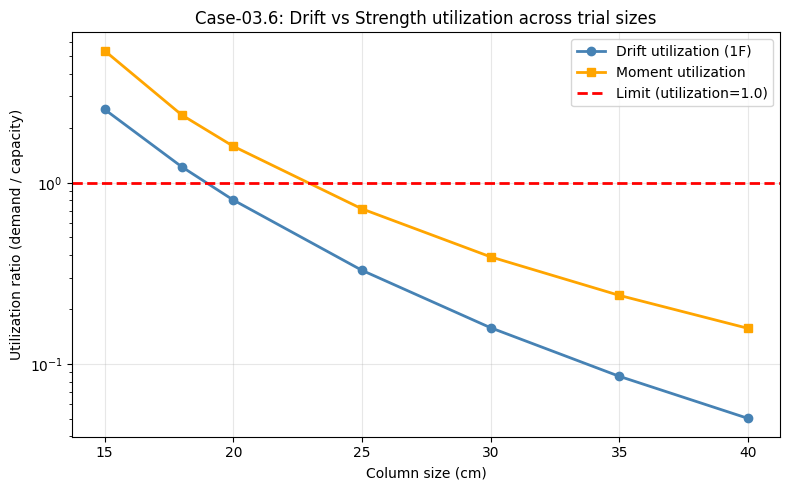

In [7]:
%matplotlib inline
import matplotlib.pyplot as plt

sizes = [r['size'] for r in results]
drift_util = [r['drift1']/DRIFT_LIMIT for r in results]
m_util_list = [r['m_util'] for r in results]

fig, ax = plt.subplots(figsize=(8,5))
ax.plot(sizes, drift_util, 'o-', color='steelblue', lw=2, label='Drift utilization (1F)')
ax.plot(sizes, m_util_list, 's-', color='orange', lw=2, label='Moment utilization')
ax.axhline(1.0, color='red', ls='--', lw=2, label='Limit (utilization=1.0)')
ax.set_xlabel('Column size (cm)')
ax.set_ylabel('Utilization ratio (demand / capacity)')
ax.set_title('Case-03.6: Drift vs Strength utilization across trial sizes')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_yscale('log')
plt.tight_layout()
plt.show()

## 總結表

In [8]:
print("="*55)
print("Case-03.6 快速強度檢核結果總結")
print("="*55)
print(f"{'Mu(需求)':<20}{Mu:.3f} kN-m")
print(f"{'Vu(需求)':<20}{Vu:.3f} kN")
print(f"{'Pu(需求, 概估)':<20}{Pu:.2f} kN")
print(f"{'Governing條件':<20}強度(應變相容法修正後)")
print(f"{'第一個雙PASS尺寸':<20}{first_pass['size']}cm")
print(f"{'  該尺寸M利用率':<20}{first_pass['m_util']:.1%}")
print(f"{'  該尺寸drift利用率':<20}{first_pass['drift1']/DRIFT_LIMIT:.1%}")
print()
print("Case-03.6 [PASS] -- 可以進到 Case-04(桃園案例, 套用實際X向/Y向構架)")

Case-03.6 快速強度檢核結果總結
Mu(需求)              22.608 kN-m
Vu(需求)              0.000 kN
Pu(需求, 概估)          147.60 kN
Governing條件         強度(應變相容法修正後)
第一個雙PASS尺寸          25cm
  該尺寸M利用率           71.8%
  該尺寸drift利用率       32.9%

Case-03.6 [PASS] -- 可以進到 Case-04(桃園案例, 套用實際X向/Y向構架)
